In [1]:
!pip -q install transformers datasets accelerate evaluate scikit-learn pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00


In [2]:
import os
import random
import numpy as np
import pandas as pd
import torch

In [3]:
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    default_data_collator,
    set_seed,
)

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
MODEL_NAME = "bluenguyen/longformer-phobert-base-4096"
DATA_PATH = "Vietnamese-company-dataset.csv"
OUTPUT_DIR = "longformer_vietnamese_policy_model"

MAX_LENGTH = 4096
BATCH_SIZE = 10
GRAD_ACCUM_STEPS = 4
NUM_EPOCHS = 5
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
FAST_DEV_RUN = False
FREEZE_EMBEDDINGS = False
SEED = 42

set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("Model:", MODEL_NAME)

Device: cuda
Model: bluenguyen/longformer-phobert-base-4096


In [5]:
df = pd.read_csv(DATA_PATH)
print(df.shape)


(205, 7)


In [6]:
display(df.head(3))
print("\nPhân bố nhãn:")
print(df["label_name"].value_counts())
print("\nĐộ dài ký tự trung bình:", int(df["text"].str.len().mean()))

,id,company_name,policy_style,text,label_name,label_id,char_length
0,cong_tac_chi_phi_007,Công ty TNHH Giải pháp Số Mekong,synthetic_vietnamese_internal_policy,QUY CHẾ CÔNG TÁC VÀ THANH TOÁN CHI PHÍ - CÔNG ...,cong_tac_chi_phi,3,2349
1,bao_mat_du_lieu_024,Công ty TNHH Giải pháp Số Mekong,synthetic_vietnamese_internal_policy,CHÍNH SÁCH BẢO MẬT VÀ PHÂN LOẠI DỮ LIỆU - CÔNG...,bao_mat_du_lieu,0,2542
2,bao_mat_du_lieu_032,Công ty Cổ phần Dịch vụ Dữ liệu Đông Dương,synthetic_vietnamese_internal_policy,CHÍNH SÁCH BẢO MẬT VÀ PHÂN LOẠI DỮ LIỆU - CÔNG...,bao_mat_du_lieu,0,2628



Phân bố nhãn:
label_name
ai_noi_bo           45
cong_tac_chi_phi    40
bao_mat_du_lieu     40
email_thiet_bi      40
nghi_phep_remote    40
Name: count, dtype: int64

Độ dài ký tự trung bình: 2603


In [7]:
sample_row = df.sample(1, random_state=SEED).iloc[0]
print("ID:", sample_row["id"])
print("Label:", sample_row["label_name"])
print("-" * 100)
print(sample_row["text"][:2500], "...")

ID: cong_tac_chi_phi_029
Label: cong_tac_chi_phi
----------------------------------------------------------------------------------------------------
QUY CHẾ CÔNG TÁC VÀ THANH TOÁN CHI PHÍ - CÔNG TY TNHH THƯƠNG MẠI VÀ CÔNG NGHỆ MINH TÂM
Ban hành nội bộ, áp dụng toàn công ty

Ngày hiệu lực: 26/08/2026. Áp dụng cho nhân viên chính thức phát sinh hoạt động công tác, khảo sát, gặp gỡ đối tác hoặc tham dự sự kiện theo phân công của Công ty TNHH Thương mại và Công nghệ Minh Tâm.

Chính sách này quy định việc đề nghị công tác, đặt vé, lưu trú, tạm ứng, thanh toán chi phí và quyết toán sau chuyến đi đối với nhân sự của công ty.

Nguyên tắc tài chính: mọi khoản chi phải gắn với mục đích công việc hợp lệ, có phê duyệt trước hoặc phê duyệt bổ sung trong tình huống khẩn cấp và được lưu chứng từ đầy đủ.

Quy định chi tiết: Chi phí cá nhân như nâng hạng ghế, minibar, giải trí, mua sắm hoặc đưa đón không liên quan đến công việc không thuộc phạm vi thanh toán của công ty. Chi phí lưu trú, taxi, ăn ở v

In [8]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label_id"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label_id"]
)

if FAST_DEV_RUN:
    train_df = train_df.groupby("label_id").head(8).reset_index(drop=True)
    val_df = val_df.groupby("label_id").head(3).reset_index(drop=True)
    test_df = test_df.groupby("label_id").head(3).reset_index(drop=True)

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

Train: (143, 7)
Val  : (31, 7)
Test : (31, 7)


In [9]:
label2id = {label: idx for idx, label in enumerate(sorted(df["label_name"].unique()))}
id2label = {idx: label for label, idx in label2id.items()}

print("label2id =", label2id)
print("id2label =", id2label)

label2id = {'ai_noi_bo': 0, 'bao_mat_du_lieu': 1, 'cong_tac_chi_phi': 2, 'email_thiet_bi': 3, 'nghi_phep_remote': 4}
id2label = {0: 'ai_noi_bo', 1: 'bao_mat_du_lieu', 2: 'cong_tac_chi_phi', 3: 'email_thiet_bi', 4: 'nghi_phep_remote'}


In [10]:
train_df["label_id"] = train_df["label_name"].map(label2id)
val_df["label_id"] = val_df["label_name"].map(label2id)
test_df["label_id"] = test_df["label_name"].map(label2id)

In [11]:
train_ds = Dataset.from_pandas(train_df[["text", "label_id"]].reset_index(drop=True))
val_ds = Dataset.from_pandas(val_df[["text", "label_id"]].reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df[["text", "label_id"]].reset_index(drop=True))

train_ds, val_ds, test_ds

(Dataset({
     features: ['text', 'label_id'],
     num_rows: 143
 }),
 Dataset({
     features: ['text', 'label_id'],
     num_rows: 31
 }),
 Dataset({
     features: ['text', 'label_id'],
     num_rows: 31
 }))

In [12]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.model_max_length

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/916 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/311 [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/22.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

4096

In [13]:
def tokenize_function(batch):
    enc = tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )
    enc["labels"] = batch["label_id"]

    global_masks = []
    for input_ids in enc["input_ids"]:
        gmask = [0] * len(input_ids)
        if len(gmask) > 0:
            gmask[0] = 1
        global_masks.append(gmask)
    enc["global_attention_mask"] = global_masks
    return enc

In [14]:
train_tokenized = train_ds.map(tokenize_function, batched=True, remove_columns=train_ds.column_names)
val_tokenized = val_ds.map(tokenize_function, batched=True, remove_columns=val_ds.column_names)
test_tokenized = test_ds.map(tokenize_function, batched=True, remove_columns=test_ds.column_names)

Map:   0%|          | 0/143 [00:00<?, ? examples/s]

Map:   0%|          | 0/31 [00:00<?, ? examples/s]

Map:   0%|          | 0/31 [00:00<?, ? examples/s]

In [15]:
train_tokenized.set_format("torch")
val_tokenized.set_format("torch")
test_tokenized.set_format("torch")

train_tokenized

Dataset({
    features: ['input_ids', 'attention_mask', 'labels', 'global_attention_mask'],
    num_rows: 143
})

In [16]:
sample = train_tokenized[0]
for k, v in sample.items():
    print(k, type(v), v.shape if hasattr(v, "shape") else len(v))
print("global_attention_mask đầu chuỗi:", sample["global_attention_mask"][:10])

input_ids <class 'torch.Tensor'> torch.Size([4096])
attention_mask <class 'torch.Tensor'> torch.Size([4096])
labels <class 'torch.Tensor'> torch.Size([])
global_attention_mask <class 'torch.Tensor'> torch.Size([4096])
global_attention_mask đầu chuỗi: tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])


In [17]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id,
)

if FREEZE_EMBEDDINGS:
    for param in model.longformer.embeddings.parameters():
        param.requires_grad = False

model.to(device)
print("Model loaded.")

pytorch_model.bin:   0%|          | 0.00/637M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: bluenguyen/longformer-phobert-base-4096
Key                                                               | Status     | 
------------------------------------------------------------------+------------+-
roberta.embeddings.position_ids                                   | UNEXPECTED | 
roberta.encoder.layer.{0...11}.attention.self.key_global.bias     | UNEXPECTED | 
roberta.encoder.layer.{0...11}.attention.self.value_global.bias   | UNEXPECTED | 
roberta.encoder.layer.{0...11}.attention.self.query_global.bias   | UNEXPECTED | 
roberta.encoder.layer.{0...11}.attention.self.query_global.weight | UNEXPECTED | 
roberta.encoder.layer.{0...11}.attention.self.key_global.weight   | UNEXPECTED | 
roberta.encoder.layer.{0...11}.attention.self.value_global.weight | UNEXPECTED | 
lm_head.layer_norm.bias                                           | UNEXPECTED | 
lm_head.dense.bias                                                | UNEXPECTED | 
lm_head

Model loaded.


In [18]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

In [19]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=10,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=WEIGHT_DECAY,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    save_total_limit=2,
)

In [20]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    data_collator=default_data_collator,
    compute_metrics=compute_metrics,
)

In [21]:
train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,1.568422,0.354839,0.213400
2,No log,1.517861,0.451613,0.299567
3,6.005681,1.472152,0.677419,0.582655
4,6.005681,1.417055,0.709677,0.618039
5,5.416107,1.398312,0.741935,0.659272


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=20, training_loss=5.710893821716309, metrics={'train_runtime': 198.3943, 'train_samples_per_second': 3.604, 'train_steps_per_second': 0.101, 'total_flos': 1505035774894080.0, 'train_loss': 5.710893821716309, 'epoch': 5.0})

In [22]:
def tokenize_function(batch):
    enc = tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )
    enc["labels"] = batch["label_id"]

    global_masks = []
    for input_ids in enc["input_ids"]:
        gmask = [0] * len(input_ids)
        if len(gmask) > 0:
            gmask[0] = 1
        global_masks.append(gmask)
    enc["global_attention_mask"] = global_masks
    return enc

In [23]:
train_tokenized = train_ds.map(tokenize_function, batched=True, remove_columns=train_ds.column_names)
val_tokenized = val_ds.map(tokenize_function, batched=True, remove_columns=val_ds.column_names)
test_tokenized = test_ds.map(tokenize_function, batched=True, remove_columns=test_ds.column_names)

Map:   0%|          | 0/143 [00:00<?, ? examples/s]

Map:   0%|          | 0/31 [00:00<?, ? examples/s]

Map:   0%|          | 0/31 [00:00<?, ? examples/s]

In [24]:
train_tokenized.set_format("torch")
val_tokenized.set_format("torch")
test_tokenized.set_format("torch")

train_tokenized

Dataset({
    features: ['input_ids', 'attention_mask', 'labels', 'global_attention_mask'],
    num_rows: 143
})

In [25]:
sample = train_tokenized[0]
for k, v in sample.items():
    print(k, type(v), v.shape if hasattr(v, "shape") else len(v))
print("global_attention_mask đầu chuỗi:", sample["global_attention_mask"][:10])

input_ids <class 'torch.Tensor'> torch.Size([4096])
attention_mask <class 'torch.Tensor'> torch.Size([4096])
labels <class 'torch.Tensor'> torch.Size([])
global_attention_mask <class 'torch.Tensor'> torch.Size([4096])
global_attention_mask đầu chuỗi: tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])


In [26]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id,
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: bluenguyen/longformer-phobert-base-4096
Key                                                               | Status     | 
------------------------------------------------------------------+------------+-
roberta.embeddings.position_ids                                   | UNEXPECTED | 
roberta.encoder.layer.{0...11}.attention.self.key_global.bias     | UNEXPECTED | 
roberta.encoder.layer.{0...11}.attention.self.value_global.bias   | UNEXPECTED | 
roberta.encoder.layer.{0...11}.attention.self.query_global.bias   | UNEXPECTED | 
roberta.encoder.layer.{0...11}.attention.self.query_global.weight | UNEXPECTED | 
roberta.encoder.layer.{0...11}.attention.self.key_global.weight   | UNEXPECTED | 
roberta.encoder.layer.{0...11}.attention.self.value_global.weight | UNEXPECTED | 
lm_head.layer_norm.bias                                           | UNEXPECTED | 
lm_head.dense.bias                                                | UNEXPECTED | 
lm_head

In [27]:
if FREEZE_EMBEDDINGS:
    for param in model.longformer.embeddings.parameters():
        param.requires_grad = False

model.to(device)
print("Model loaded.")

Model loaded.


In [28]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

In [29]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=10,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=WEIGHT_DECAY,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    save_total_limit=2,
)

In [30]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    data_collator=default_data_collator,
    compute_metrics=compute_metrics,
)

In [31]:
train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,1.554719,0.451613,0.352107
2,No log,1.511656,0.741935,0.668333
3,5.989180,1.459237,0.870968,0.846429
4,5.989180,1.410187,0.838710,0.840702
5,5.388424,1.385049,0.903226,0.906524


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=20, training_loss=5.688801956176758, metrics={'train_runtime': 204.2334, 'train_samples_per_second': 3.501, 'train_steps_per_second': 0.098, 'total_flos': 1505035774894080.0, 'train_loss': 5.688801956176758, 'epoch': 5.0})

In [32]:
val_metrics = trainer.evaluate(val_tokenized)
test_metrics = trainer.evaluate(test_tokenized)

print("Validation metrics:", val_metrics)
print("Test metrics:", test_metrics)

Validation metrics: {'eval_loss': 1.3850489854812622, 'eval_accuracy': 0.9032258064516129, 'eval_f1_macro': 0.906524064171123, 'eval_runtime': 1.6155, 'eval_samples_per_second': 19.189, 'eval_steps_per_second': 2.476, 'epoch': 5.0}
Test metrics: {'eval_loss': 1.3948144912719727, 'eval_accuracy': 0.9032258064516129, 'eval_f1_macro': 0.8929487179487179, 'eval_runtime': 1.6192, 'eval_samples_per_second': 19.145, 'eval_steps_per_second': 2.47, 'epoch': 5.0}


In [33]:
pred_output = trainer.predict(test_tokenized)
preds = np.argmax(pred_output.predictions, axis=-1)
y_true = pred_output.label_ids

print(classification_report(y_true, preds, target_names=[id2label[i] for i in sorted(id2label)]))

                  precision    recall  f1-score   support

       ai_noi_bo       0.78      1.00      0.88         7
 bao_mat_du_lieu       1.00      0.50      0.67         6
cong_tac_chi_phi       1.00      1.00      1.00         6
  email_thiet_bi       0.86      1.00      0.92         6
nghi_phep_remote       1.00      1.00      1.00         6

        accuracy                           0.90        31
       macro avg       0.93      0.90      0.89        31
    weighted avg       0.92      0.90      0.89        31



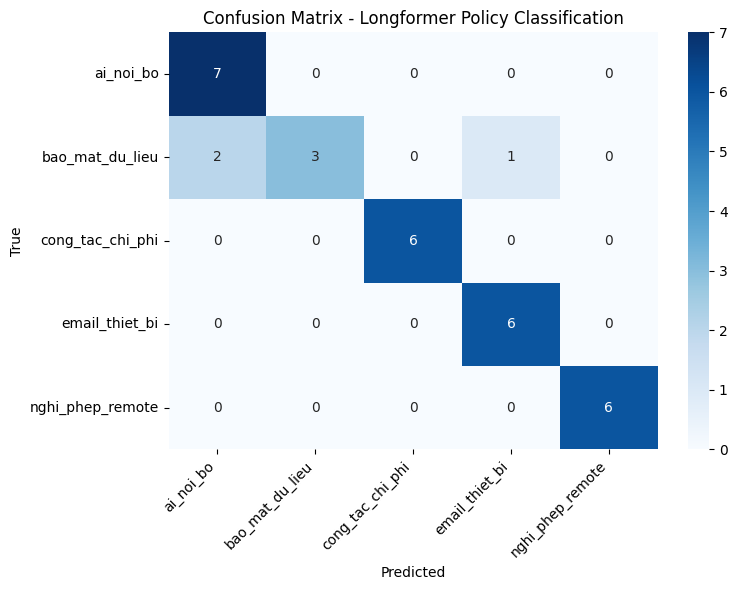

In [34]:
cm = confusion_matrix(y_true, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[id2label[i] for i in sorted(id2label)],
    yticklabels=[id2label[i] for i in sorted(id2label)],
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Longformer Policy Classification")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [35]:
def predict_policy(text, model, tokenizer, max_length=MAX_LENGTH):
    model.eval()
    enc = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="pt",
    )
    global_attention_mask = torch.zeros_like(enc["input_ids"])
    global_attention_mask[:, 0] = 1
    enc["global_attention_mask"] = global_attention_mask
    enc = {k: v.to(device) for k, v in enc.items()}

    with torch.no_grad():
        outputs = model(**enc)
        probs = torch.softmax(outputs.logits, dim=-1).squeeze(0).cpu().numpy()
        pred_id = int(np.argmax(probs))

    return {
        "pred_id": pred_id,
        "pred_label": id2label[pred_id],
        "probabilities": {id2label[i]: float(probs[i]) for i in range(len(probs))}
    }

In [36]:
demo_text = '''
CHÍNH SÁCH SỬ DỤNG AI TRONG CÔNG VIỆC

Nhân sự chỉ được dùng các công cụ AI nằm trong danh mục đã được công ty phê duyệt.
Không được nhập mã nguồn chưa công bố, dữ liệu khách hàng, hợp đồng chưa ký, khóa truy cập
hoặc tài liệu thuộc mức Mật vào dịch vụ AI công cộng. Mọi nội dung do AI tạo ra trước khi gửi
khách hàng phải được con người kiểm tra lại về số liệu, pháp lý, giọng điệu thương hiệu và
mức độ phù hợp với bối cảnh nghiệp vụ. Bộ phận phụ trách phải lưu vết prompt mẫu, phạm vi dữ liệu
đầu vào và hướng dẫn kiểm soát để phục vụ kiểm tra nội bộ khi cần.
'''

result = predict_policy(demo_text, model, tokenizer)
result

{'pred_id': 2,
 'pred_label': 'cong_tac_chi_phi',
 'probabilities': {'ai_noi_bo': 0.1900731325149536,
  'bao_mat_du_lieu': 0.1959691196680069,
  'cong_tac_chi_phi': 0.22509832680225372,
  'email_thiet_bi': 0.2234283983707428,
  'nghi_phep_remote': 0.1654309630393982}}

In [38]:
save_dir = "/content/drive/MyDrive/Cybersoft/AI/Generative_Agents/created_models"
trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)
print("Saved to:", save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /content/drive/MyDrive/Cybersoft/AI/Generative_Agents/created_models
